In [ ]:
import funky.snanawrap as f
import funky.nreblocks as nb
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import pytorch_lightning as pl
import corner
import pandas as pd
import emcee
import pickle
rng=np.random.default_rng(seed=1)

In [ ]:
with open("/home/ubuntu/SNANA/nre/nreSims.pickle", 'rb') as pikel: sims = pickle.load(pikel)
N = 5500  # select number of TRAINING sims
N_val = 700  # VALIDATION sims
N_lc = 100  # lc per sim (maximum possible over all sims)  ## smoothing gives 100 points

# training
theta = np.empty((N, 2))
mu = np.empty((N, N_lc))
zhd = np.empty((N, N_lc))
for i in range(N):
    theta[i] = (sims[i].get('omega'), sims[i].get('w'))
    zhd[i], mu[i] = f.smoother(sims[i].get('zhd'), sims[i].get('mu'))

# validation
theta_val = np.empty((N_val, 2))
mu_val = np.empty((N_val, N_lc))
zhd_val = np.empty((N_val, N_lc))
for i, j in enumerate(range(N, N + N_val)):
    theta_val[i] = (sims[j].get('omega'), sims[j].get('w'))
    zhd_val[i], mu_val[i] = f.smoother(sims[j].get('zhd'), sims[j].get('mu'))

In [ ]:
# standardise
theta_mean, theta_std = theta.mean(axis=0), theta.std(axis=0)
mu_mean, mu_std = mu.mean(axis=0), mu.std(axis=0)

mu = torch.tensor((mu - mu_mean) / mu_std).float()
theta = torch.tensor((theta - theta_mean) / theta_std).float()
x = mu

mu_val = torch.tensor((mu_val - mu_mean) / mu_std).float()
theta_val = torch.tensor((theta_val - theta_mean) / theta_std).float()
x_val = mu_val
# save means and stds, we need them to standardise the test
np.savez("/home/ubuntu/SNANA/nre/gioTesting/meansNstdsSummarisedNoZ.npz", theta_mean=theta_mean, theta_std=theta_std, mu_mean=mu_mean, mu_std=mu_std)

nre = nb.NeuralRatioEstimator(x_dim=N_lc, theta_dim=2, hidden_dim=1020, layers=5)
batch_size = 100

dataset_train, dataset_val = TensorDataset(x, theta), TensorDataset(x_val, theta_val)

train_loader = DataLoader(dataset_train, batch_size=batch_size, num_workers=3, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=batch_size, num_workers=3, shuffle=False)

early_stop_callback = pl.callbacks.EarlyStopping(monitor="val_loss", patience=10, mode="min")
checkpoint_callback = pl.callbacks.ModelCheckpoint(every_n_epochs=10, save_top_k=-1)

logger = pl.loggers.CSVLogger('nreTestLogs', name="summariesNoZ")
trainer = pl.Trainer(max_epochs=250, logger=logger, callbacks=[early_stop_callback, checkpoint_callback])
nre.train()
trainer.fit(model=nre, train_dataloaders=train_loader, val_dataloaders=val_loader)

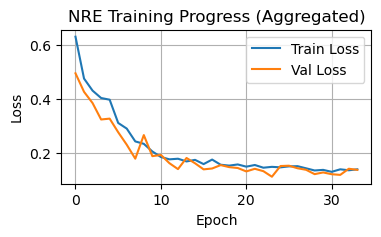

In [4]:
metrics = pd.read_csv(f"nreTestLogs/summariesNoZ/FINAL_VERSION/metrics.csv")

# aggregate by epoch to remove NaNs
epoch_metrics = metrics.groupby('epoch').max()

plt.figure(figsize=(4, 2))

plt.plot(epoch_metrics.index, epoch_metrics['train_loss'], label='Train Loss')
plt.plot(epoch_metrics.index, epoch_metrics['val_loss'], label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.title('NRE Training Progress (Aggregated)')
plt.show()

In [ ]:
npLoad = np.load("/home/ubuntu/SNANA/nre/gioTesting/meansNstdsSummarisedNoZ.npz")
theta_mean = npLoad["theta_mean"]
theta_std = npLoad["theta_std"]
mu_mean = npLoad["mu_mean"]
mu_std = npLoad["mu_std"]
npLoad.close()
nre = nb.NeuralRatioEstimator.load_from_checkpoint('nreTestLogs/summariesNoZ/FINAL_VERSION/checkpoints/epoch=29-step=1650.ckpt', x_dim=100, theta_dim=2, hidden_dim=1020, layers=5)
nre.eval()

In [ ]:
muReal, zReal = f.extract_mu_zhd_from_file('/home/ubuntu/SNANA/salt2mus/realdata/SALT2mu_realdata.FITRES')
zReal, muReal = f.smoother(zReal, muReal)

ndim, nwalkers = 2, 32
sampler = emcee.EnsembleSampler(nwalkers, ndim, nb.log_post, args=(muReal, theta_mean, theta_std, mu_mean, mu_std, nre,))

pos = rng.uniform((0, -3), (1, 0), size=(nwalkers, ndim))
sampler.run_mcmc(pos, 5000, progress=True)
with open('nreTestLogs/summariesNoZ/FINAL_VERSION/sampler.pkl', 'wb') as file: pickle.dump(sampler, file)

Autocorrelation time: [32.72893514 35.32657308]


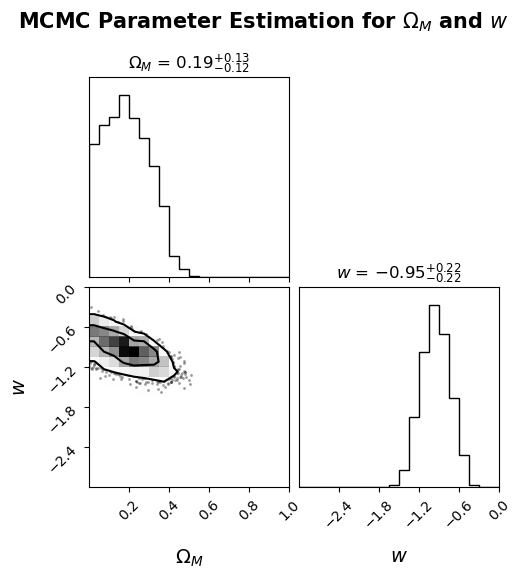

In [7]:
with open('nreTestLogs/summariesNoZ/FINAL_VERSION/sampler.pkl', 'rb') as file: sampler = pickle.load(file)
print("Autocorrelation time:", sampler.get_autocorr_time(discard=1000))
flat_samples = sampler.get_chain(discard=1000, thin=50, flat=True)  # get chain, look for what's flat
fig = corner.corner(
    flat_samples, 
    range=[(0, 1), (-3, 0)], 
    labels=[r"$\Omega_M$", r"$w$"],
    show_titles=True,                 
    title_kwargs={"fontsize": 12},    
    label_kwargs={"fontsize": 14},    
    color="black",                 
    hist_kwargs={"linewidth": 1},   
    hist_bin_factor=1,
    levels=(0.68,0.95),          
    fill_contours=False,               
    plot_datapoints=True,            
    data_kwargs={"alpha": 0.4}
)
fig.suptitle("MCMC Parameter Estimation for $\\Omega_M$ and $w$", fontsize=15, fontweight="bold", y=1.05)
plt.show()